<a href="https://colab.research.google.com/github/AdityaAksar/AdityaAksar/blob/main/Teknologi_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Eksplorasi Data**
# **Studi Kasus : Tweet Bencana**

List Anggota Kelompok
1. Gilang Aldiansyah_F52123012
2. Aditya Zaldy_F52123027
3. Felicia Claudia Pandelaki_F52123048

## **Persiapan : Import Data dan Library**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Dataset_Simulasi_Tweet_Bencana.csv')

In [ ]:
df.head()

,tweet_id,tanggal,lokasi,sentimen,teks,panjang_karakter,jumlah_kata
0,1,2024-01-06,Jakarta,Positif,Info resmi gempa 6.5 SR di Jakarta,34,7
1,2,2024-01-07,Jakarta,Positif,Relawan sudah bergerak ke Jakarta membantu korban,49,7
2,3,2024-01-08,Palu,Negatif,Banjir melanda wilayah Palu pagi ini,36,6
3,4,2024-01-02,Bandung,Negatif,Info resmi gempa 6.5 SR di Bandung,34,7
4,5,2024-01-03,Jakarta,Netral,Info resmi gempa 6.5 SR di Jakarta,34,7


## **1. Cek ukuran Dataset dan Tipe Data**

In [ ]:
# Ukuran Dataset
print(f"Ukuran dataset (Row, Column): \n {df.shape}")

# Cek tipe data
print(f"\nTipe data: \n {df.dtypes}")


Ukuran dataset (Row, Column): 
 (500, 7)

Tipe data: 
 tweet_id             int64
tanggal             object
lokasi              object
sentimen            object
teks                object
panjang_karakter     int64
jumlah_kata          int64
dtype: object


## **2. Identifikasi Missing Value**

In [ ]:
# Cek Missing Value
print(df.isnull().sum())

tweet_id            0
tanggal             0
lokasi              0
sentimen            0
teks                0
panjang_karakter    0
jumlah_kata         0
dtype: int64


Cek Outlier pada Dataset

In [ ]:
df.dtypes

,0
tweet_id,int64
tanggal,datetime64[ns]
lokasi,object
sentimen,object
teks,object
panjang_karakter,int64
jumlah_kata,int64


Kolom: tweet_id

Batas Bawah: -248.5
Batas Atas: 749.5
Jumlah Outlier: 0



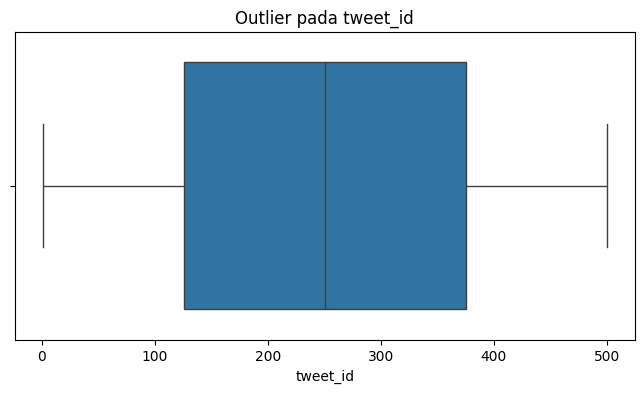

Kolom: panjang_karakter

Batas Bawah: 12.5
Batas Atas: 72.5
Jumlah Outlier: 0



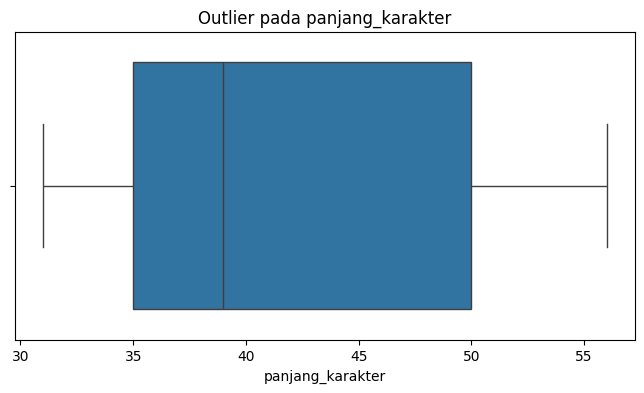

Kolom: jumlah_kata

Batas Bawah: 4.5
Batas Atas: 8.5
Jumlah Outlier: 99



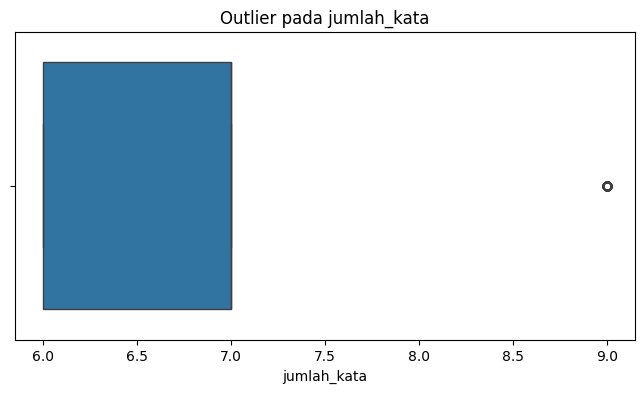

In [ ]:
numeric = df.select_dtypes(include=['int64', 'float64'])

for column in numeric:
  # Interquartile Range (IQR)
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  # Batas
  batas_bawah = Q1 - (1.5 * IQR)
  batas_atas = Q3 + (1.5 * IQR)

  outlier = df[(df[column] < batas_bawah) | (df[column] > batas_atas)]
  print(f"Kolom: {column}\n")
  print(f"Batas Bawah: {batas_bawah}\nBatas Atas: {batas_atas}")
  print(f"Jumlah Outlier: {len(outlier)}\n")
  plt.figure(figsize=(8,4))
  sns.boxplot(x=df[column])
  plt.title(f'Outlier pada {column}')
  plt.xlabel(column)
  plt.show()


## **3. Hitung Statistik Deskriptif**

In [ ]:
print(df.describe())

numeric = ['panjang_karakter', 'jumlah_kata']

print(f"\nMean: \n{df[numeric].mean()}")
print(f"\nMedian: \n{df[numeric].median()}")
print(f"\nModus: \n{df[numeric].mode()}")

         tweet_id  panjang_karakter  jumlah_kata
count  500.000000        500.000000    500.00000
mean   250.500000         42.282000      7.00600
std    144.481833          7.961989      1.08827
min      1.000000         31.000000      6.00000
25%    125.750000         35.000000      6.00000
50%    250.500000         39.000000      7.00000
75%    375.250000         50.000000      7.00000
max    500.000000         56.000000      9.00000

Mean: 
panjang_karakter    42.282
jumlah_kata          7.006
dtype: float64

Median: 
panjang_karakter    39.0
jumlah_kata          7.0
dtype: float64

Modus: 
   panjang_karakter  jumlah_kata
0                35            7


## **4. Hitung Distribusi Kategori**

Frekuensi Sentimen: 
sentimen
Negatif    303
Netral     121
Positif     76
Name: count, dtype: int64

Persentase Sentimen (%): 
sentimen
Negatif    60.6
Netral     24.2
Positif    15.2
Name: proportion, dtype: float64


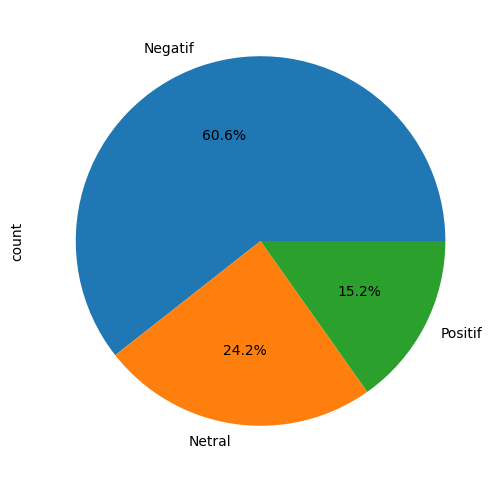

In [ ]:
print(f"Frekuensi Sentimen: \n{df['sentimen'].value_counts()}")

print(f"\nPersentase Sentimen (%): \n{df['sentimen'].value_counts(normalize=True) * 100}")

df['sentimen'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.show()

## **5. Visualisasi (bar chart, line chart, box plot, histogram)**

/tmp/ipython-input-1225/3019954843.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimen', data=df, palette='viridis')
/tmp/ipython-input-1225/3019954843.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lokasi', data=df, palette='viridis')
/tmp/ipython-input-1225/3019954843.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentimen', y='panjang_karakter', data=df, palette='Set2')


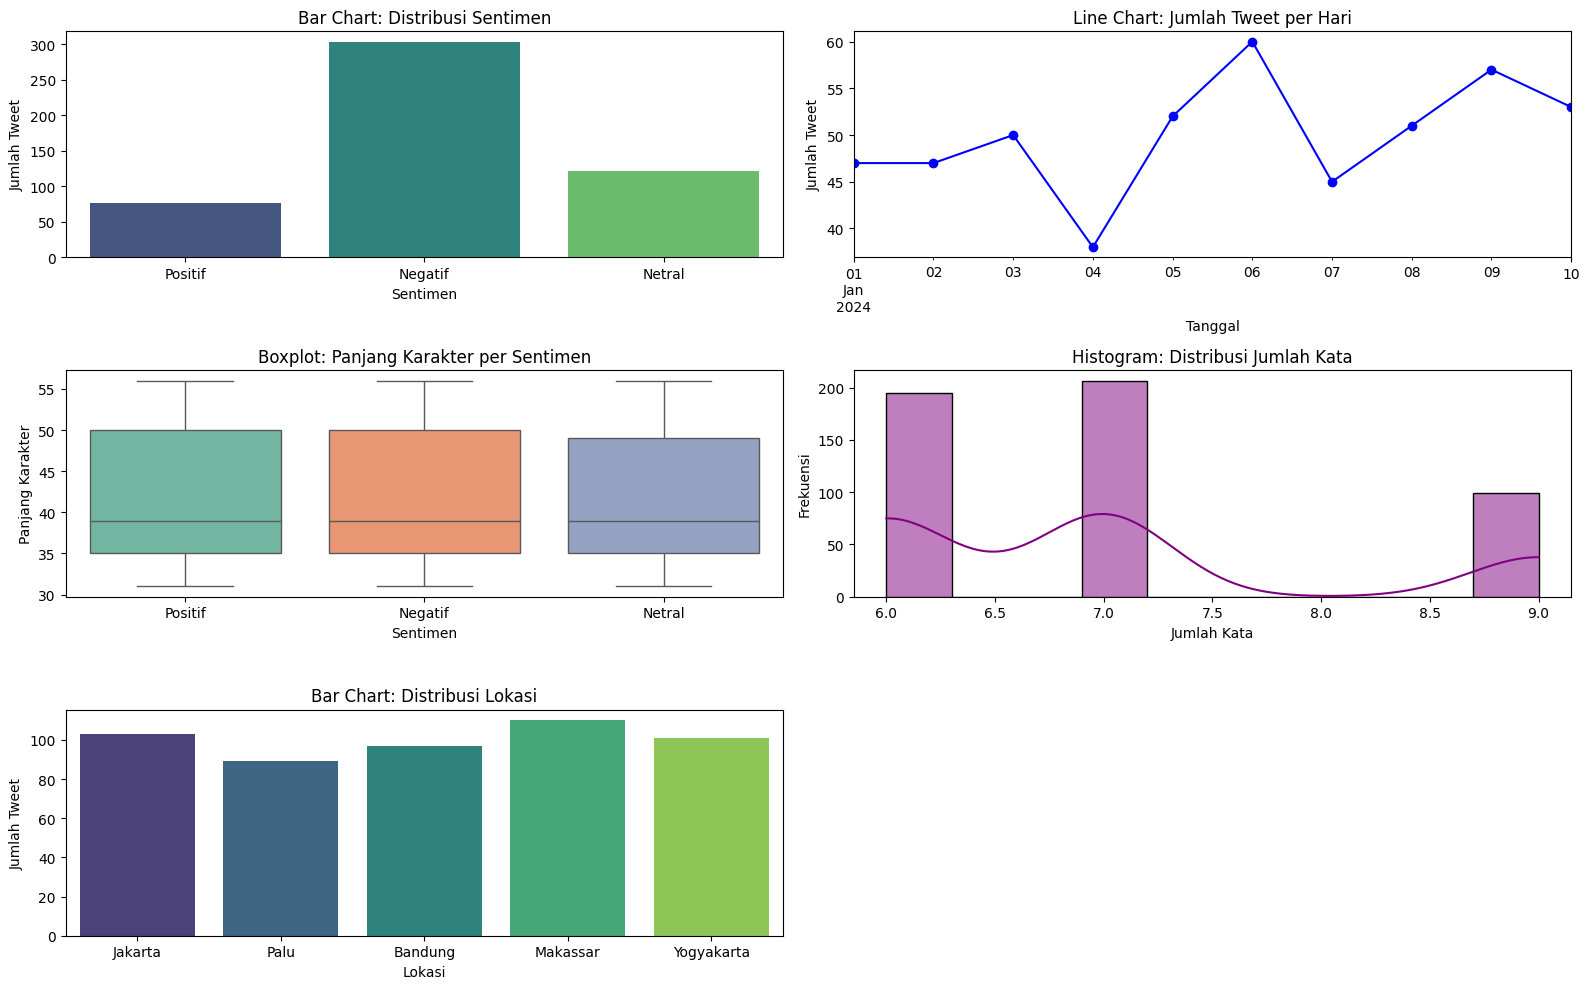

In [ ]:
plt.figure(figsize=(16, 10))

# Bar Chart

# Distribusi Sentimen
plt.subplot(3,2,1)
# plt.bar(df['sentimen'].value_counts().index, df['sentimen'].value_counts().values)
sns.countplot(x='sentimen', data=df, palette='viridis')
plt.title('Bar Chart: Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')

# Distribusi Lokasi
plt.subplot(3,2,5)
sns.countplot(x='lokasi', data=df, palette='viridis')
plt.title('Bar Chart: Distribusi Lokasi')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Tweet')

# Line Chart
plt.subplot(3, 2, 2)
df['tanggal'] = pd.to_datetime(df['tanggal'])
tweet_per_hari = df.groupby('tanggal').size()
tweet_per_hari.plot(kind='line', marker='o', color='b')
plt.title('Line Chart: Jumlah Tweet per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Tweet')

# Box Plot
plt.subplot(3, 2, 3)
sns.boxplot(x='sentimen', y='panjang_karakter', data=df, palette='Set2')
plt.title('Boxplot: Panjang Karakter per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Panjang Karakter')

# Histogram
plt.subplot(3, 2, 4)
sns.histplot(df['jumlah_kata'], bins=10, kde=True, color='purple')
plt.title('Histogram: Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')


plt.tight_layout()
plt.show()

## **6. Analisis Korelasi**

Analisis Korelasi untuk melihat hubungan antara
1. Panjang Karakter vs Jumlah Kata (Scatter Plot)
2. Lokasi vs Sentimen (Stacked Bar Chart)
3. Tanggal vs Sentimen (Multi Line Chart)

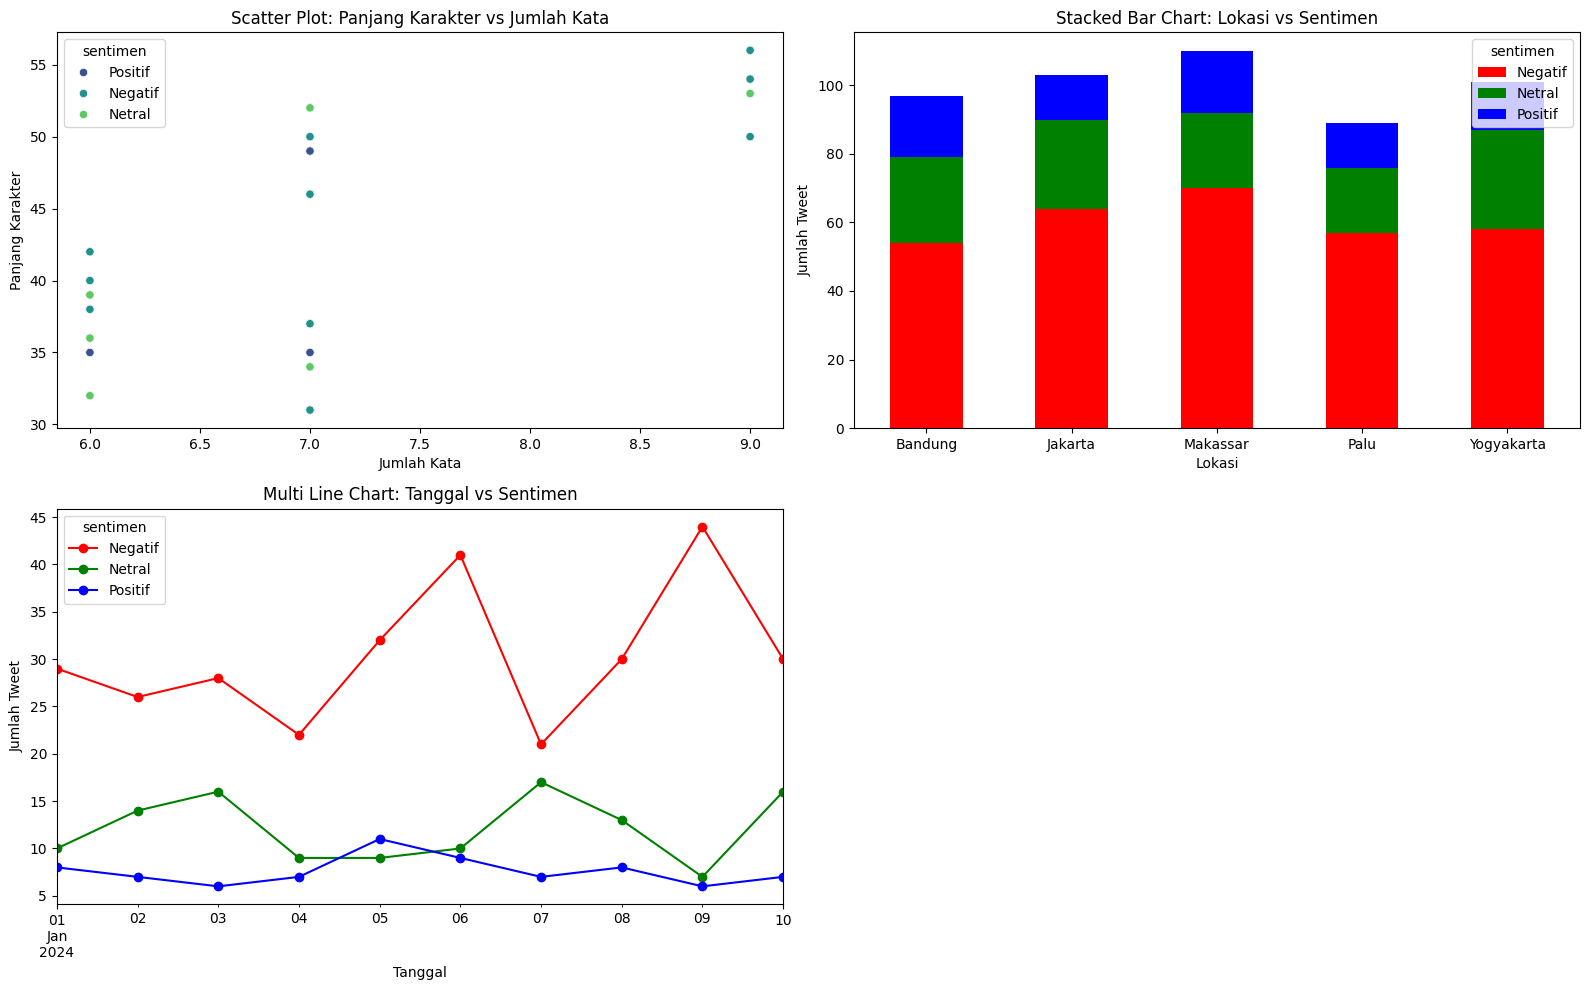

In [ ]:
plt.figure(figsize=(16,10))

# Scatter Plot untuk Panjang Karakter vs Jumlah Kata
plt.subplot(2,2,1)
sns.scatterplot(x='jumlah_kata', y='panjang_karakter', data=df, hue='sentimen', palette='viridis')
plt.title('Scatter Plot: Panjang Karakter vs Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Panjang Karakter')

# Stacked Bar Chart untuk Lokasi vs Sentimen
ax2 = plt.subplot(2,2,2)
lokasi_sentimen = pd.crosstab(df['lokasi'], df['sentimen'])
lokasi_sentimen.plot(kind='bar', stacked=True, color=['r', 'g', 'b'], ax=ax2)
plt.title('Stacked Bar Chart: Lokasi vs Sentimen')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=0)

# Multi Line Chart untuk Tanggal vs Sentimen
ax3 = plt.subplot(2,2,3)
df['tanggal'] = pd.to_datetime(df['tanggal'])
tanggal_sentimen = df.groupby(['tanggal', 'sentimen']).size().unstack()
tanggal_sentimen.plot(kind='line', marker='o', color=['r', 'g', 'b'], ax=ax3)
plt.title('Multi Line Chart: Tanggal vs Sentimen')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Tweet')

plt.tight_layout()
plt.show()




## **7. Insight berdasarkan hasil analisis**